# Exploration 04 — classical models, learning curves and effective number of parameters

> **Exploratory** (CLAUDE.md, "Exploration"). **Inputs:** the headline-legal feature sets (Z and R only), plus one
> clearly labeled exploration-only set that adds DFT outputs. **Data:** cross-validation inside the nested training
> sets S_(s,N) only. No test set is read.

**Part 4 of the classical analysis**, and the baseline the quantum model will be compared against. It uses:
- the cleaned features and feature sets from notebook 02;
- the feature scaling and target transform chosen by CV in notebook 03 (`results/explore03_preprocessing.json`),
  applied to every model alike.

**Protocol** (the one M3 and the quantum model follow):
- each S_(s,N), s ∈ {0, 1, 2}, N ∈ {100, 300, 1000}, is exactly the training set the quantum model will get;
- inside it, `KFold(5, shuffle=True, random_state=s)`, the **same folds for every model and feature set**, so all
  differences are paired;
- hyperparameters are chosen by CV MAE. Every fitted transform (scaling, PCA, target) sits inside the estimator and
  is refit on each fold's training part, and negative predictions are clipped at 0 D;
- reported: MAE and RMSE of the pooled out-of-fold predictions at the chosen hyperparameters.

The best-of-grid CV error is slightly optimistic (more so for bigger grids). The unbiased numbers come from the
single final test evaluation (M7). Runtime: about 30 minutes.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FixedLocator, NullFormatter, NullLocator

from qm9dipole import REPO_ROOT
from qm9dipole.analysis import loglog_slope, summarize_curves
from qm9dipole.evaluate import learning_curve
from qm9dipole.explore import (EXPLORATION_ONLY_SETS, feature_sets, load_catalog, load_config, load_features,
                               load_preprocessing)
from qm9dipole.models import classical
from qm9dipole.plots import INK_SECONDARY, MODEL_COLORS, MODEL_LABELS, MUTED, SERIES, SURFACE, use_style
from qm9dipole.provenance import config_hash, save_result
from qm9dipole.splits import load_splits

use_style()
FIG_DIR = REPO_ROOT / "figures"
CFG = load_config()
features = load_features()
SETS = feature_sets(load_catalog())
PRE = load_preprocessing()
SCALING, TARGET = PRE["scaling"], PRE["target"]
splits = load_splits()
y = features["mu"]
print(f"from notebook 03: feature scaling = {SCALING}, target transform = {TARGET}")

variants = {}
for name in ("composition", "cm", "structure", "cm+structure"):
    variants[name] = SETS[name]
    if len(SETS[name]) > classical.N_COMPONENTS:
        variants[f"{name}/pca8"] = SETS[name]  # the pipeline adds PCA(8), refit in every fold
variants["structure+dft"] = SETS["structure+dft"]
frames = {name: features[cols] for name, cols in variants.items()}
for name, cols in variants.items():
    tag = "EXPLORATION ONLY (DFT outputs)" if name in EXPLORATION_ONLY_SETS else "headline-legal"
    print(f"{name:22s} {len(cols):3d} columns{' -> 8 components' if name.endswith('/pca8') else ''}  {tag}")


def make_specs(seed, fname):
    return classical.specs(seed, compressed=fname.endswith("/pca8"), scaling=SCALING, target=TARGET)

from notebook 03: feature scaling = yeo_johnson, target transform = sqrt
composition              5 columns  headline-legal
cm                      29 columns  headline-legal
cm/pca8                 29 columns -> 8 components  headline-legal
structure               31 columns  headline-legal
structure/pca8          31 columns -> 8 components  headline-legal
cm+structure            60 columns  headline-legal
cm+structure/pca8       60 columns -> 8 components  headline-legal
structure+dft           47 columns  EXPLORATION ONLY (DFT outputs)


In [3]:
def describe_grid(grid):
    if not grid:
        return "none"
    parts = []
    for key, values in grid.items():
        key = key.removeprefix("model__")
        if len(values) > 4 and all(isinstance(v, float) for v in values):
            parts.append(f"{key}: {len(values)} values, {min(values):.0e} to {max(values):.0e} (log-spaced)")
        else:
            parts.append(f"{key} ∈ {values}")
    return "; ".join(parts)


display(pd.DataFrame([{"model": MODEL_LABELS[m], "hyperparameters searched": describe_grid(classical.GRIDS[m]),
                       "candidates": int(np.prod([len(v) for v in classical.GRIDS[m].values()]))}
                      for m in classical.MODELS]).style.hide(axis="index"))

model,hyperparameters searched,candidates
mean,none,1
linear (OLS),none,1
ridge,"alpha: 15 values, 1e-04 to 1e+03 (log-spaced)",15
RBF kernel ridge,"alpha: 7 values, 1e-06 to 1e+00 (log-spaced); gamma: 9 values, 1e-03 to 1e+01 (log-spaced)",63
random forest,"max_features ∈ [1.0, 0.5, 'sqrt']; min_samples_leaf ∈ [1, 3, 5]",9
XGBoost,"max_depth ∈ [3, 5, 7]; learning_rate ∈ [0.03, 0.1]; min_child_weight ∈ [1, 5]",12


## 1. Run the grid

8 feature variants × 6 models × 3 seeds × 3 sizes = 432 tuned CV runs. Results:
`results/explore04_classical_cv.csv` (PLAN §9.2 long format, plus `representation`, `input_variant` and `inputs`).

In [4]:
run_config = {"grids": classical.GRIDS, "n_components": classical.N_COMPONENTS, "scaling": SCALING, "target": TARGET,
              "folds": "KFold(5, shuffle=True, random_state=seed)", "variants": variants,
              "split_config_hash": config_hash(splits.config), "clip_negative_predictions": True}
start = time.perf_counter()
results, _ = learning_curve(make_specs, frames, y, splits.train)
print(f"done in {(time.perf_counter() - start) / 60:.1f} min")
results.insert(0, "representation", results["features"].str.removesuffix("/pca8"))
results.insert(1, "input_variant", np.where(results["features"].str.endswith("/pca8"), "compressed", "full"))
results.insert(2, "inputs", np.where(results["features"].isin(EXPLORATION_ONLY_SETS), "Z, R + DFT outputs (exploration)", "Z, R"))
results["config_hash"] = config_hash(run_config)
save_result(results, "explore04_classical_cv", config=run_config, config_hash=config_hash(run_config),
            label="exploratory; CV inside S_(s,N) only; no test set read")
summ = summarize_curves(results)

seed 0  N=100   composition            best rbf_krr  MAE 1.072 D  ( 13.2 s for 6 models)


seed 0  N=100   cm                     best rf       MAE 1.149 D  ( 10.1 s for 6 models)


seed 0  N=100   cm/pca8                best rbf_krr  MAE 1.176 D  (  9.5 s for 6 models)


seed 0  N=100   structure              best xgb      MAE 0.749 D  ( 10.9 s for 6 models)


seed 0  N=100   structure/pca8         best rbf_krr  MAE 0.780 D  (  9.7 s for 6 models)


...

seed 2  N=1000  structure/pca8         best rbf_krr  MAE 0.784 D  ( 21.3 s for 6 models)


seed 2  N=1000  cm+structure           best xgb      MAE 0.700 D  ( 49.9 s for 6 models)


seed 2  N=1000  cm+structure/pca8      best rbf_krr  MAE 0.896 D  ( 26.1 s for 6 models)


seed 2  N=1000  structure+dft          best rbf_krr  MAE 0.311 D  ( 42.9 s for 6 models)


done in 22.7 min


## 2. Learning curves

One panel per feature variant, one line per model; means over 3 seeds ± 1 standard deviation; log–log axes (a
straight line is a power law, error ∝ N^slope). The last panel adds DFT outputs and is **exploration-only**. It
shows how much easier the problem becomes when the electron density is known.

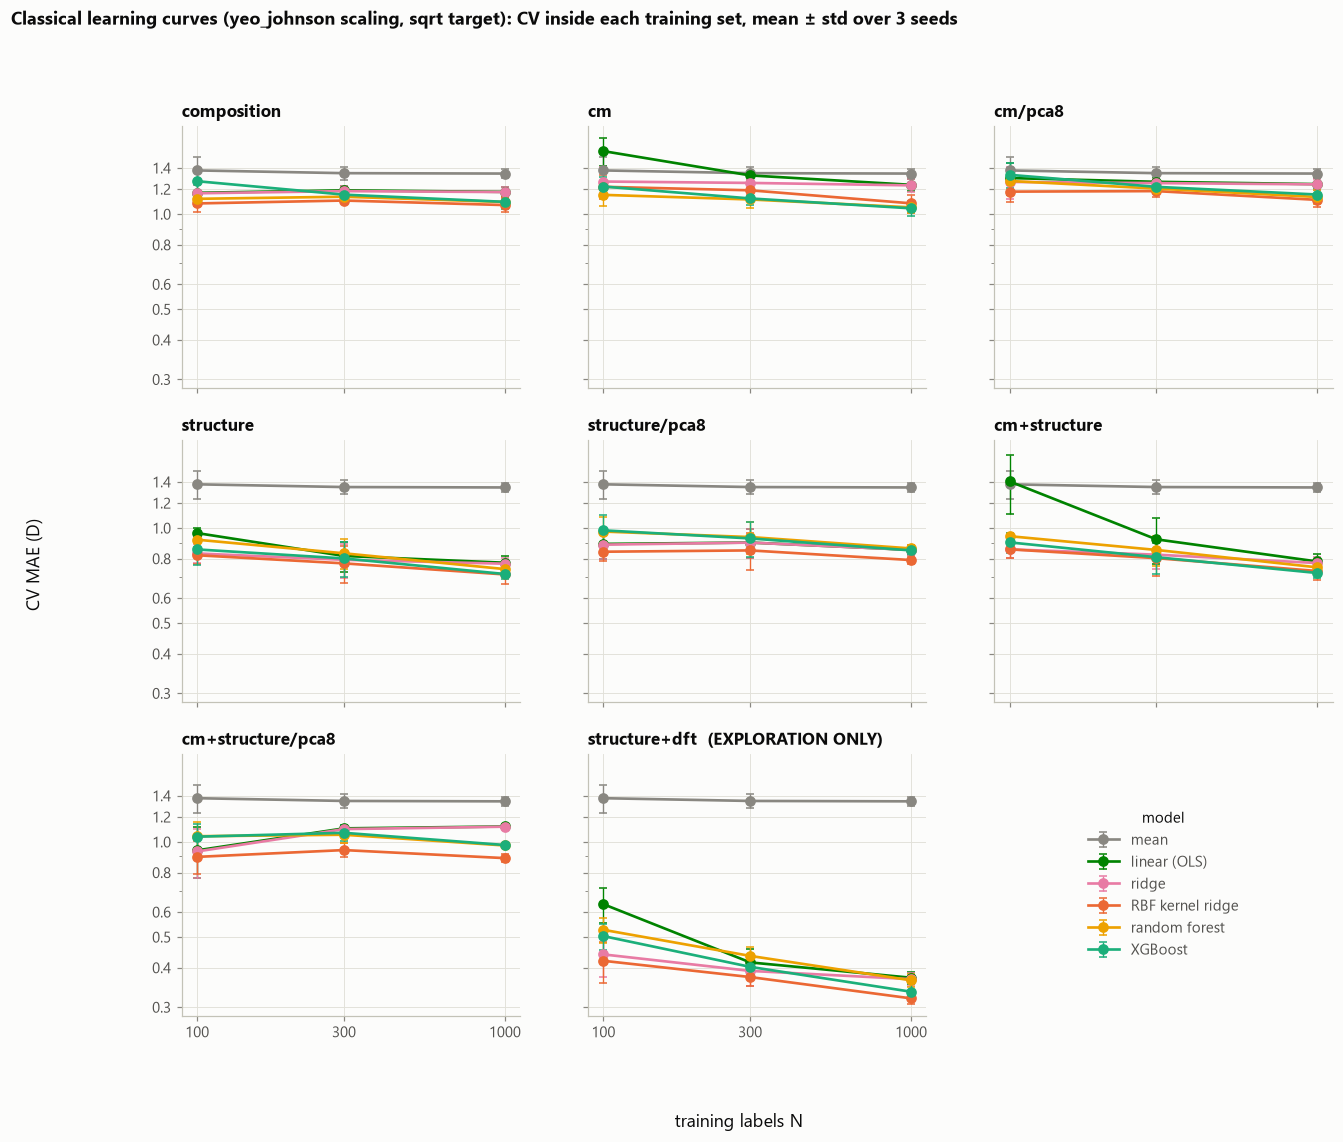

In [5]:
SIZES = sorted(results["n_train"].unique())
fig, axes = plt.subplots(3, 3, figsize=(13.5, 10.5), sharex=True, sharey=True)
for ax, fname in zip(axes.flat, variants):
    for m in classical.MODELS:
        s = summ[(summ["features"] == fname) & (summ["model"] == m)].sort_values("n_train")
        ax.errorbar(s["n_train"], s["mean"], yerr=s["std"], color=MODEL_COLORS[m], marker="o", capsize=2.5,
                    elinewidth=0.9, label=MODEL_LABELS[m])
    title = fname + ("  (EXPLORATION ONLY)" if fname in EXPLORATION_ONLY_SETS else "")
    ax.set(xscale="log", yscale="log", title=title)
    ax.xaxis.set_major_locator(FixedLocator(SIZES))
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}")
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_major_locator(FixedLocator([0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.4]))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.1f}")
    ax.yaxis.set_minor_formatter(NullFormatter())
legend_ax = axes.flat[-1]
legend_ax.axis("off")
legend_ax.legend(*axes.flat[0].get_legend_handles_labels(), loc="center", title="model", fontsize=10)
fig.supxlabel("training labels N")
fig.supylabel("CV MAE (D)")
fig.suptitle(f"Classical learning curves ({SCALING} scaling, {TARGET} target): CV inside each training set, "
             "mean ± std over 3 seeds", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.savefig(FIG_DIR / "explore04_learning_curves.png")
plt.show()

In [6]:
def pm(frame):
    return frame["mean"].map("{:.3f}".format) + " ± " + frame["std"].map("{:.3f}".format)


model_order = [MODEL_LABELS[m] for m in classical.MODELS]
for n in SIZES:
    t = summ[summ["n_train"] == n].assign(value=lambda d: pm(d), model=lambda d: d["model"].map(MODEL_LABELS))
    t = t.pivot(index="model", columns="features", values="value").loc[model_order, list(variants)]
    display(t.style.set_caption(f"CV MAE (D), mean ± std over 3 seeds, N = {n}"))

features,composition,cm,cm/pca8,structure,structure/pca8,cm+structure,cm+structure/pca8,structure+dft
model,,,,,,,,
mean,1.376 ± 0.142,1.376 ± 0.142,1.376 ± 0.142,1.376 ± 0.142,1.376 ± 0.142,1.376 ± 0.142,1.376 ± 0.142,1.376 ± 0.142
linear (OLS),1.169 ± 0.101,1.583 ± 0.158,1.301 ± 0.152,0.964 ± 0.039,0.891 ± 0.095,1.405 ± 0.299,0.941 ± 0.172,0.636 ± 0.080
ridge,1.164 ± 0.101,1.269 ± 0.144,1.265 ± 0.146,0.831 ± 0.056,0.886 ± 0.089,0.856 ± 0.055,0.933 ± 0.166,0.441 ± 0.067
RBF kernel ridge,1.082 ± 0.065,1.221 ± 0.107,1.179 ± 0.083,0.820 ± 0.052,0.842 ± 0.054,0.857 ± 0.053,0.897 ± 0.108,0.421 ± 0.062
random forest,1.118 ± 0.054,1.151 ± 0.088,1.274 ± 0.090,0.919 ± 0.046,0.975 ± 0.106,0.943 ± 0.023,1.043 ± 0.110,0.527 ± 0.049
XGBoost,1.272 ± 0.097,1.223 ± 0.091,1.332 ± 0.121,0.856 ± 0.093,0.984 ± 0.114,0.901 ± 0.066,1.039 ± 0.102,0.504 ± 0.048


features,composition,cm,cm/pca8,structure,structure/pca8,cm+structure,cm+structure/pca8,structure+dft
model,,,,,,,,
mean,1.348 ± 0.066,1.348 ± 0.066,1.348 ± 0.066,1.348 ± 0.066,1.348 ± 0.066,1.348 ± 0.066,1.348 ± 0.066,1.348 ± 0.066
linear (OLS),1.190 ± 0.042,1.326 ± 0.012,1.266 ± 0.032,0.816 ± 0.090,0.900 ± 0.097,0.921 ± 0.152,1.104 ± 0.029,0.416 ± 0.042
ridge,1.183 ± 0.041,1.256 ± 0.036,1.254 ± 0.036,0.794 ± 0.098,0.899 ± 0.096,0.824 ± 0.082,1.098 ± 0.020,0.391 ± 0.041
RBF kernel ridge,1.105 ± 0.023,1.190 ± 0.044,1.183 ± 0.049,0.773 ± 0.103,0.850 ± 0.111,0.803 ± 0.096,0.943 ± 0.049,0.374 ± 0.023
random forest,1.136 ± 0.026,1.113 ± 0.068,1.205 ± 0.038,0.832 ± 0.090,0.937 ± 0.108,0.853 ± 0.094,1.054 ± 0.059,0.436 ± 0.029
XGBoost,1.153 ± 0.035,1.122 ± 0.053,1.220 ± 0.013,0.802 ± 0.102,0.927 ± 0.117,0.809 ± 0.091,1.069 ± 0.064,0.403 ± 0.032


features,composition,cm,cm/pca8,structure,structure/pca8,cm+structure,cm+structure/pca8,structure+dft
model,,,,,,,,
mean,1.345 ± 0.044,1.345 ± 0.044,1.345 ± 0.044,1.345 ± 0.044,1.345 ± 0.044,1.345 ± 0.044,1.345 ± 0.044,1.345 ± 0.044
linear (OLS),1.177 ± 0.046,1.239 ± 0.057,1.245 ± 0.053,0.777 ± 0.040,0.853 ± 0.030,0.784 ± 0.042,1.120 ± 0.017,0.372 ± 0.017
ridge,1.175 ± 0.046,1.234 ± 0.056,1.243 ± 0.052,0.771 ± 0.034,0.853 ± 0.030,0.775 ± 0.035,1.118 ± 0.015,0.368 ± 0.018
RBF kernel ridge,1.069 ± 0.055,1.082 ± 0.071,1.110 ± 0.053,0.713 ± 0.047,0.792 ± 0.021,0.731 ± 0.044,0.889 ± 0.026,0.320 ± 0.012
random forest,1.093 ± 0.045,1.051 ± 0.041,1.134 ± 0.059,0.742 ± 0.027,0.862 ± 0.021,0.751 ± 0.026,0.975 ± 0.011,0.365 ± 0.018
XGBoost,1.094 ± 0.059,1.044 ± 0.058,1.154 ± 0.054,0.716 ± 0.023,0.850 ± 0.023,0.721 ± 0.027,0.978 ± 0.011,0.336 ± 0.018


## 3. The cost of compressing to 8 components

The quantum model takes one input per qubit. Each entry pairs a model on a full legal set with the same model on
its first 8 principal components (same seed, training set and folds) and reports compressed − full in CV MAE.
Positive means compression hurts.

In [7]:
key = ["seed", "n_train", "model", "representation"]
full = results[results["input_variant"] == "full"].set_index(key)["mae_D"]
compressed = results[results["input_variant"] == "compressed"].set_index(key)["mae_D"]
delta = (compressed - full.loc[compressed.index]).rename("delta").reset_index()
cost = delta.groupby(["representation", "model", "n_train"])["delta"].agg(["mean", "std"]).reset_index()
cost = cost.assign(value=lambda d: d["mean"].map("{:+.3f}".format) + " ± " + d["std"].map("{:.3f}".format),
                   model=lambda d: d["model"].map(MODEL_LABELS))
display(cost.pivot(index=["representation", "model"], columns="n_train", values="value")
        .style.set_caption("Δ CV MAE (D), compressed − full, mean ± std over seeds"))

## 4. Regularization at small N: linear vs ridge

Ordinary least squares has no penalty. With 60 features and 80 training molecules per fold (N = 100) it can fit the
training data almost exactly and generalize badly. Ridge adds an L2 penalty chosen by CV. Section 6 shows how many
effective parameters that leaves.

In [8]:
legal_full = ["composition", "cm", "structure", "cm+structure"]
lr = summ[summ["model"].isin(["linear", "ridge"]) & summ["features"].isin(legal_full)]
lr = lr.pivot_table(index=["features", "n_train"], columns="model", values="mean")
lr["ridge − linear"] = lr["ridge"] - lr["linear"]
display(lr.style.format("{:.3f}").set_caption("CV MAE (D), mean over seeds"))

## 5. How fast does each model learn?

The slope of log(MAE) against log(N) over N = 100 → 1000. More negative means each extra label helps more; 0 means
more labels don't help. With three points per line this is a summary, not a fit to trust closely.

In [9]:
slopes = (summ.groupby(["model", "features"])[["n_train", "mean"]]
          .apply(lambda s: loglog_slope(s["n_train"].to_numpy(), s["mean"].to_numpy()))
          .unstack("features").loc[list(classical.MODELS), list(variants)])
slopes.index = slopes.index.map(MODEL_LABELS)
display(slopes.style.format("{:+.2f}").set_caption("learning-curve slope d log(MAE) / d log(N)"))

features,composition,cm,cm/pca8,structure,structure/pca8,cm+structure,cm+structure/pca8,structure+dft
model,,,,,,,,
mean,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01,-0.01
linear (OLS),+0.00,-0.11,-0.02,-0.09,-0.02,-0.25,+0.07,-0.23
ridge,+0.00,-0.01,-0.01,-0.03,-0.02,-0.04,+0.08,-0.08
RBF kernel ridge,-0.01,-0.05,-0.03,-0.06,-0.03,-0.07,-0.00,-0.12
random forest,-0.01,-0.04,-0.05,-0.09,-0.05,-0.10,-0.03,-0.16
XGBoost,-0.06,-0.07,-0.06,-0.08,-0.06,-0.10,-0.03,-0.18


## 6. Effective number of parameters

How flexible is each fitted model? Following ESL §7.6, a model that predicts ŷ = S y uses
**df = tr(S) = Σᵢ ∂ŷᵢ/∂yᵢ** effective parameters: the total influence of each training label on its own fitted
value (`src/qm9dipole/complexity.py`).
- mean: 1. OLS: 1 + number of features (all of them, always).
- ridge: 1 + Σⱼ dⱼ²/(dⱼ² + α). Each direction of the design is shrunk, and α trades parameters for stability.
- kernel ridge: 1 + tr(K(K+αI)⁻¹) − 1ᵀK(K+αI)⁻¹1/n on a centred target. **The same formula applies to the quantum
  kernel in M4**, so the two kernels' effective flexibility can be compared directly.
- random forest and XGBoost are not linear smoothers. Their df is estimated with Ye's generalized degrees of
  freedom: perturb the labels with small noise, refit 20 times, and add up how much each prediction follows its own
  label's noise.

Each model is refit on the whole training set at its CV-chosen hyperparameters. df is measured in the space each
model is fit in, the transformed target z = standardized √|μ| (notebook 03). A linear smoother's hat matrix
depends only on the inputs and the penalty, never on the target, so ridge and kernel ridge get exact values. Noise
for the Monte-Carlo estimate is added to z, never to |μ| itself, where it could push a label below 0 and leave √
undefined. Exact df for every legal full set; the Monte-Carlo estimate (slower) for the two richest legal sets.

In [10]:
from qm9dipole.complexity import effective_df

rng = np.random.default_rng(2026)
df_rows = []
start = time.perf_counter()
for r in results[results["features"].isin(legal_full)].itertuples():
    if r.model in ("rf", "xgb") and r.features not in ("structure", "cm+structure"):
        continue
    ids = splits.train[r.seed][r.n_train]
    X, ys = features.loc[ids, variants[r.features]].to_numpy(), y.loc[ids].to_numpy()
    est = make_specs(r.seed, r.features)[r.model][0].set_params(**json.loads(r.hyperparams))
    dfv, se, method = effective_df(est, X, ys, rng, n_rep=20)
    fitted = est.fit(X, ys)
    train_mse = float(np.mean((np.clip(fitted.predict(X), 0, None) - ys) ** 2))
    df_rows.append({"seed": r.seed, "n_train": r.n_train, "model": r.model, "features": r.features, "df": dfv,
                    "df_se": se, "method": method, "train_mse": train_mse, "cv_mse": r.rmse_D ** 2,
                    "n_features": len(variants[r.features])})
dof = pd.DataFrame(df_rows)
save_result(dof, "explore04_effective_df", n_rep=20, label="exploratory; df of models refit on S_(s,N)")
print(f"effective df for {len(dof)} fitted models in {(time.perf_counter() - start) / 60:.1f} min")
tab = dof.groupby(["features", "model", "n_train"])["df"].mean().unstack("n_train")
tab.index = pd.MultiIndex.from_tuples([(f, MODEL_LABELS[m]) for f, m in tab.index])
display(tab.style.format("{:.1f}").set_caption("effective number of parameters df (mean over seeds)"))

effective df for 180 fitted models in 10.7 min


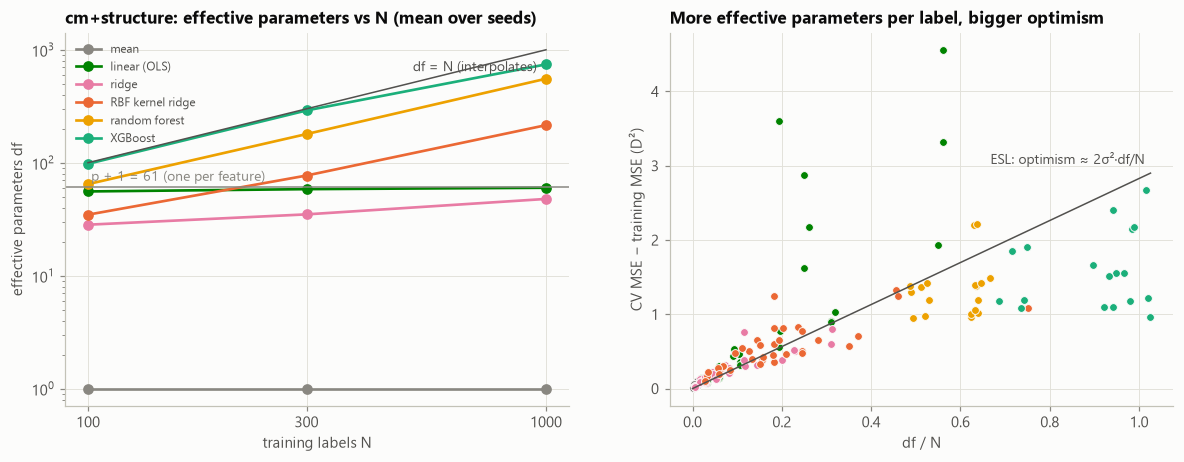

σ² for the guide line: lowest mean CV MSE at N = 1000 (1.414 D²)


In [11]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.4))
sub = dof[dof["features"] == "cm+structure"].groupby(["model", "n_train"])["df"].mean().reset_index()
for m in classical.MODELS:
    s = sub[sub["model"] == m]
    ax0.plot(s["n_train"], s["df"], color=MODEL_COLORS[m], marker="o", label=MODEL_LABELS[m])
ax0.plot(SIZES, SIZES, color=INK_SECONDARY, linewidth=1)
ax0.annotate("df = N (interpolates)", (SIZES[-1], SIZES[-1]), xytext=(-6, -14), textcoords="offset points",
             ha="right", color=INK_SECONDARY, fontsize=9)
ax0.axhline(len(variants["cm+structure"]) + 1, color=MUTED, linewidth=1)
ax0.annotate(f"p + 1 = {len(variants['cm+structure']) + 1} (one per feature)", (SIZES[0], len(variants["cm+structure"]) + 1), xytext=(2, 4),
             textcoords="offset points", color=MUTED, fontsize=9)
ax0.set(xscale="log", yscale="log", xlabel="training labels N", ylabel="effective parameters df",
        title="cm+structure: effective parameters vs N (mean over seeds)")
ax0.xaxis.set_major_locator(FixedLocator(SIZES))
ax0.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}")
ax0.xaxis.set_minor_locator(NullLocator())
ax0.legend(fontsize=8, loc="upper left")

gap = dof.assign(gap=dof["cv_mse"] - dof["train_mse"], ratio=dof["df"] / dof["n_train"])
for m in classical.MODELS:
    s = gap[gap["model"] == m]
    ax1.scatter(s["ratio"], s["gap"], color=MODEL_COLORS[m], s=26, edgecolors=SURFACE, linewidths=0.6, label=MODEL_LABELS[m])
sigma2 = float(dof[dof["n_train"] == SIZES[-1]].groupby(["model", "features"])["cv_mse"].mean().min())
grid = np.linspace(0, gap["ratio"].max(), 50)
ax1.plot(grid, 2 * sigma2 * grid, color=INK_SECONDARY, linewidth=1)
ax1.annotate("ESL: optimism ≈ 2σ²·df/N", (grid[-1], 2 * sigma2 * grid[-1]), xytext=(-4, 6), textcoords="offset points",
             ha="right", color=INK_SECONDARY, fontsize=9)
ax1.set(xlabel="df / N", ylabel="CV MSE − training MSE (D²)", title="More effective parameters per label, bigger optimism")
fig.savefig(FIG_DIR / "explore04_effective_df.png")
plt.show()
print(f"σ² for the guide line: lowest mean CV MSE at N = {SIZES[-1]} ({sigma2:.3f} D²)")

### Ridge: trading parameters for stability

ESL Figure 3.8 for our data: ridge coefficient paths on the structure set (S_(0,1000), chosen scaling) as the
penalty moves the fit from 1 effective parameter (all coefficients 0) to OLS (all 32). The vertical line marks the
penalty CV chose. The five largest coefficients at that point are named.

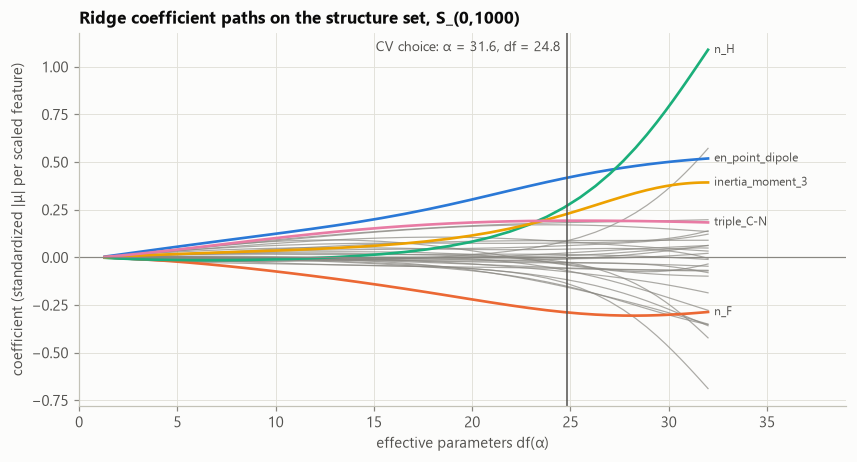

In [12]:
from sklearn.linear_model import Ridge
from qm9dipole.complexity import ridge_df

ids = splits.train[0][1000]
est0 = make_specs(0, "structure")["ridge"][0]
pipe0 = est0.regressor
Xs = pipe0[:-1].fit_transform(features.loc[ids, SETS["structure"]].to_numpy())
zs = (y.loc[ids].to_numpy() - y.loc[ids].mean()) / y.loc[ids].std()
alphas = np.logspace(-3, 5, 70)
paths = np.array([Ridge(alpha=a).fit(Xs, zs).coef_ for a in alphas])
dfs = np.array([ridge_df(Xs, a) for a in alphas])
chosen = json.loads(results.query("seed == 0 and n_train == 1000 and model == 'ridge' and features == 'structure'")
                    ["hyperparams"].iloc[0])["regressor__model__alpha"]
df_chosen = ridge_df(Xs, chosen)
top5 = np.argsort(-np.abs(Ridge(alpha=chosen).fit(Xs, zs).coef_))[:5]

fig, ax = plt.subplots(figsize=(9, 4.4))
for j in range(Xs.shape[1]):
    if j not in top5:
        ax.plot(dfs, paths[:, j], color=MUTED, linewidth=0.8, alpha=0.7)
for color, j in zip(SERIES, top5):
    ax.plot(dfs, paths[:, j], color=color, linewidth=1.75)
    ax.annotate(SETS["structure"][j], (dfs[0], paths[0, j]), xytext=(4, 0), textcoords="offset points",
                color=INK_SECONDARY, fontsize=8, va="center")  # alphas ascend, so index 0 is the high-df end
ax.axvline(df_chosen, color=INK_SECONDARY, linewidth=1)
ax.annotate(f"CV choice: α = {chosen:.3g}, df = {df_chosen:.1f}", (df_chosen, ax.get_ylim()[1]), xytext=(-4, -12),
            textcoords="offset points", ha="right", color=INK_SECONDARY, fontsize=9)
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.set_xlim(0, dfs[0] * 1.22)
ax.set(xlabel="effective parameters df(α)", ylabel="coefficient (standardized |μ| per scaled feature)",
       title="Ridge coefficient paths on the structure set, S_(0,1000)")
fig.savefig(FIG_DIR / "explore04_ridge_paths.png")
plt.show()

## 7. The classical baseline to beat

The best (model, feature set) by mean CV MAE at each N, separately for full legal inputs, 8-component legal inputs
(the like-for-like comparator for an 8-qubit model), and the exploration-only set.

In [13]:
summ["inputs"] = np.select([summ["features"].isin(EXPLORATION_ONLY_SETS), summ["features"].str.endswith("/pca8")],
                           ["exploration only (+ DFT)", "legal, 8 components"], "legal, full")
best = summ[summ["model"] != "mean"].sort_values("mean").groupby(["n_train", "inputs"]).head(1)
best = best.assign(model=best["model"].map(MODEL_LABELS), **{"CV MAE (D)": pm(best)})
display(best.sort_values(["n_train", "inputs"])[["n_train", "inputs", "model", "features", "CV MAE (D)"]]
        .style.hide(axis="index"))
mean_row = summ[(summ["model"] == "mean") & (summ["features"] == "composition")]
print("mean baseline:", ", ".join(f"N={r.n_train}: {r.mean:.3f} D" for r in mean_row.itertuples()))

n_train,inputs,model,features,CV MAE (D)
100,exploration only (+ DFT),RBF kernel ridge,structure+dft,0.421 ± 0.062
100,"legal, 8 components",RBF kernel ridge,structure/pca8,0.842 ± 0.054
100,"legal, full",RBF kernel ridge,structure,0.820 ± 0.052
300,exploration only (+ DFT),RBF kernel ridge,structure+dft,0.374 ± 0.023
300,"legal, 8 components",RBF kernel ridge,structure/pca8,0.850 ± 0.111
300,"legal, full",RBF kernel ridge,structure,0.773 ± 0.103
1000,exploration only (+ DFT),RBF kernel ridge,structure+dft,0.320 ± 0.012
1000,"legal, 8 components",RBF kernel ridge,structure/pca8,0.792 ± 0.021
1000,"legal, full",RBF kernel ridge,structure,0.713 ± 0.047


mean baseline: N=100: 1.376 D, N=300: 1.348 D, N=1000: 1.345 D


## Summary

1. **The best headline-legal baseline is RBF kernel ridge on the 31 structure features, at every N:** CV MAE 0.820,
   0.773 and 0.713 D at N = 100, 300 and 1000, against 1.38, 1.35 and 1.35 D for the mean (47% lower at
   N = 1000). XGBoost matches it at N = 1000 (0.716 D) but trails at small N. Random forest and ridge follow
   closely.
2. **Representation matters more than the model.** structure < cm+structure < cm ≈ composition for every model.
   The Coulomb spectrum alone barely beats composition (1.08 vs 1.07 D for kernel ridge at N = 1000) and adds
   nothing once the structure features are present.
3. **The like-for-like comparator for an 8-qubit model** is kernel ridge on 8 principal components of the
   structure set: 0.842, 0.850 and 0.792 D. Compression costs little at N = 100 (+0.02 D) and +0.08 D at N = 1000.
   On the Coulomb spectrum it even helps at N = 100 (−0.04 D), since fewer, cleaner inputs suit few labels.
   cm+structure compresses badly (+0.16 to +0.34 D at N = 1000).
4. **Regularization decides small-N performance.** OLS on 60 features fails at N = 100 (1.41 D vs ridge's
   0.86 D); the gap disappears by N = 1000.
5. **Learning curves are shallow.** Slopes are −0.06 for kernel ridge on structure and −0.10 at best, so ten
   times more labels cut MAE by only about 13%. The small-N end is where a label-efficiency comparison is decided.
6. **Effective number of parameters.** Ridge uses 5–48 (depending on the feature set) and kernel ridge 35–215,
   growing with N as CV lets it become more flexible. Random forests use about 0.55–0.65 N. XGBoost uses about
   N at N = 100 and 300, behaving like an interpolator, and 0.75 N at N = 1000. The optimism (CV − training MSE)
   follows ESL's 2σ²·df/N for the linear smoothers and forests; OLS exceeds it at small N (collinearity) and
   boosting stays below it.
7. **Exploration only:** adding the DFT outputs (Mulliken charges, polarizability, orbital energies, …) halves the
   error, to 0.320 D at N = 1000 for kernel ridge. That is the information a structure-only model has to recover.

**For M3 and M4:** an 8-qubit quantum kernel model on 8 principal components of the structure features should be
compared with ≈ 0.84 D at N = 100 and ≈ 0.79 D at N = 1000 (classical kernel ridge, same inputs). The best
classical model on any legal input reaches 0.82 and 0.71 D. Its effective number of parameters, tr(S) of the
fidelity kernel, can be read off with the same formula as RBF kernel ridge's.